In [1]:
# 1) Import libraries

import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from IPython.display import display

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# 2) Define file paths

processed_dir = "../data/processed"
models_dir = "../models"

artifacts_path = os.path.join(processed_dir, "preprocessing_artifacts.joblib")
best_model_path = os.path.join(models_dir, "best_nids_model.joblib")

print("Processed directory:", processed_dir)
print("Models directory:", models_dir)

Processed directory: ../data/processed
Models directory: ../models


In [3]:
# 3) Load preprocessing artifacts

artifacts = joblib.load(artifacts_path)

scaler = artifacts["scaler"]
label_encoder = artifacts["label_encoder"]
selected_columns = artifacts["selected_columns"]

print("Preprocessing artifacts loaded successfully.")
print("Number of selected columns:", len(selected_columns))
print("Classes:", list(label_encoder.classes_))

Preprocessing artifacts loaded successfully.
Number of selected columns: 47
Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']


In [4]:
# 4) Load test dataset

if os.path.exists(os.path.join(processed_dir, "X_test.npy")):
    X_test = np.load(os.path.join(processed_dir, "X_test.npy"))
    y_test = np.load(os.path.join(processed_dir, "y_test.npy"))
    print("Loaded X_test and y_test from .npy files")
else:
    X_test = pd.read_csv(os.path.join(processed_dir, "X_test.csv")).values
    y_test = pd.read_csv(os.path.join(processed_dir, "y_test.csv")).values.ravel()
    print("Loaded X_test and y_test from .csv files")

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Loaded X_test and y_test from .npy files
X_test shape: (504402, 47)
y_test shape: (504402,)


In [5]:
# 5) Load best model

best_model = joblib.load(best_model_path)

print("Best model loaded successfully.")
print("Model type:", type(best_model).__name__)

Best model loaded successfully.
Model type: DecisionTreeClassifier


In [6]:
# 6) Predict on test data

X_test = X_test.astype(np.float32)

y_pred = best_model.predict(X_test)

print("Prediction completed.")
print("First 10 encoded predictions:", y_pred[:10])

Prediction completed.
First 10 encoded predictions: [0 0 0 0 0 0 7 4 2 0]


In [7]:
# 7) Decode labels

true_labels = label_encoder.inverse_transform(y_test)
pred_labels = label_encoder.inverse_transform(y_pred)

print("First 10 true labels:")
print(true_labels[:10])

print("\nFirst 10 predicted labels:")
print(pred_labels[:10])

First 10 true labels:
['BENIGN' 'BENIGN' 'BENIGN' 'BENIGN' 'BENIGN' 'BENIGN' 'FTP-Patator'
 'DoS Hulk' 'DDoS' 'BENIGN']

First 10 predicted labels:
['BENIGN' 'BENIGN' 'BENIGN' 'BENIGN' 'BENIGN' 'BENIGN' 'FTP-Patator'
 'DoS Hulk' 'DDoS' 'BENIGN']


In [8]:
# 8) Overall evaluation metrics

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

metrics_df = pd.DataFrame([{
    "Accuracy": round(acc, 4),
    "Weighted Precision": round(precision, 4),
    "Weighted Recall": round(recall, 4),
    "Weighted F1": round(f1, 4)
}])

print("Overall Metrics:")
display(metrics_df)

Overall Metrics:


,Accuracy,Weighted Precision,Weighted Recall,Weighted F1
0,0.998,0.998,0.998,0.998


In [9]:
# 9) Classification report

report_dict = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

print("Classification Report:")
display(report_df)

Classification Report:


,precision,recall,f1-score,support
BENIGN,0.998986,0.999148,0.999067,419227.00000
Bot,0.839050,0.813299,0.825974,391.00000
DDoS,0.999961,0.999844,0.999902,25603.00000
DoS GoldenEye,0.996577,0.990763,0.993662,2057.00000
DoS Hulk,0.997111,0.998293,0.997702,34569.00000
DoS Slowhttptest,0.963740,0.965583,0.964661,1046.00000
DoS slowloris,0.973929,0.971216,0.972571,1077.00000
FTP-Patator,0.999158,1.000000,0.999579,1187.00000
Heartbleed,0.000000,0.000000,0.000000,2.00000
Infiltration,1.000000,0.857143,0.923077,7.00000


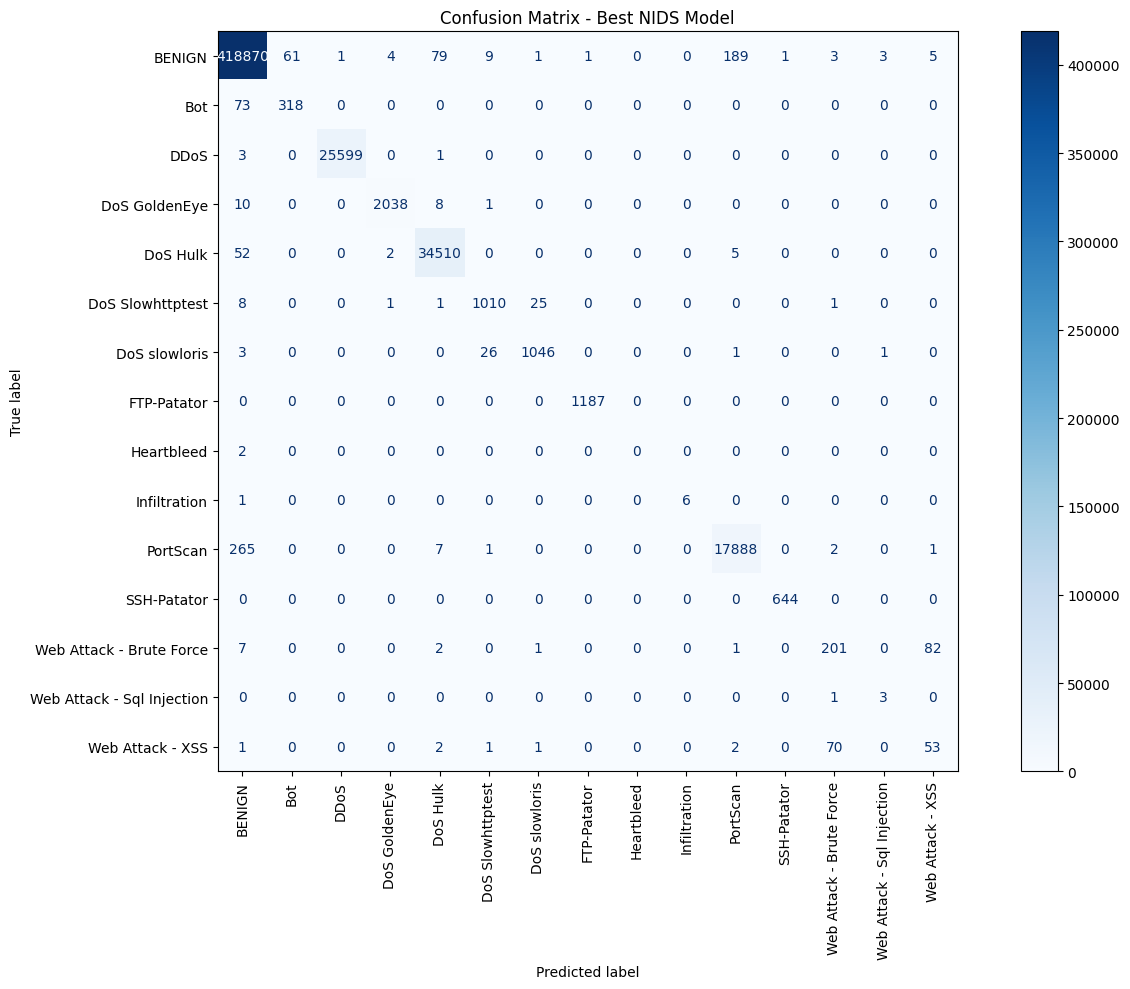

In [10]:
# 10) Confusion matrix

fig, ax = plt.subplots(figsize=(14, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=label_encoder.classes_,
    xticks_rotation=90,
    cmap="Blues",
    ax=ax
)

ax.set_title("Confusion Matrix - Best NIDS Model")
plt.tight_layout()
plt.show()

In [11]:
# 11) Per-class performance summary

label_metrics = report_df.loc[
    [cls for cls in label_encoder.classes_ if cls in report_df.index],
    ["precision", "recall", "f1-score", "support"]
].copy()

label_metrics = label_metrics.sort_values("f1-score", ascending=False)

print("Per-class performance:")
display(label_metrics)

Per-class performance:


,precision,recall,f1-score,support
DDoS,0.999961,0.999844,0.999902,25603.0
FTP-Patator,0.999158,1.000000,0.999579,1187.0
SSH-Patator,0.998450,1.000000,0.999224,644.0
BENIGN,0.998986,0.999148,0.999067,419227.0
DoS Hulk,0.997111,0.998293,0.997702,34569.0
DoS GoldenEye,0.996577,0.990763,0.993662,2057.0
PortScan,0.989052,0.984805,0.986924,18164.0
DoS slowloris,0.973929,0.971216,0.972571,1077.0
DoS Slowhttptest,0.963740,0.965583,0.964661,1046.0
Infiltration,1.000000,0.857143,0.923077,7.0


Top 20 important features:


,Feature,Importance
0,Destination Port,0.293926
38,Init_Win_bytes_forward,0.206820
41,min_seg_size_forward,0.065288
39,Init_Win_bytes_backward,0.047288
9,Bwd Packet Length Max,0.038842
2,Total Fwd Packets,0.035507
35,ACK Flag Count,0.034698
1,Flow Duration,0.032963
17,Fwd IAT Std,0.032402
18,Fwd IAT Min,0.025454


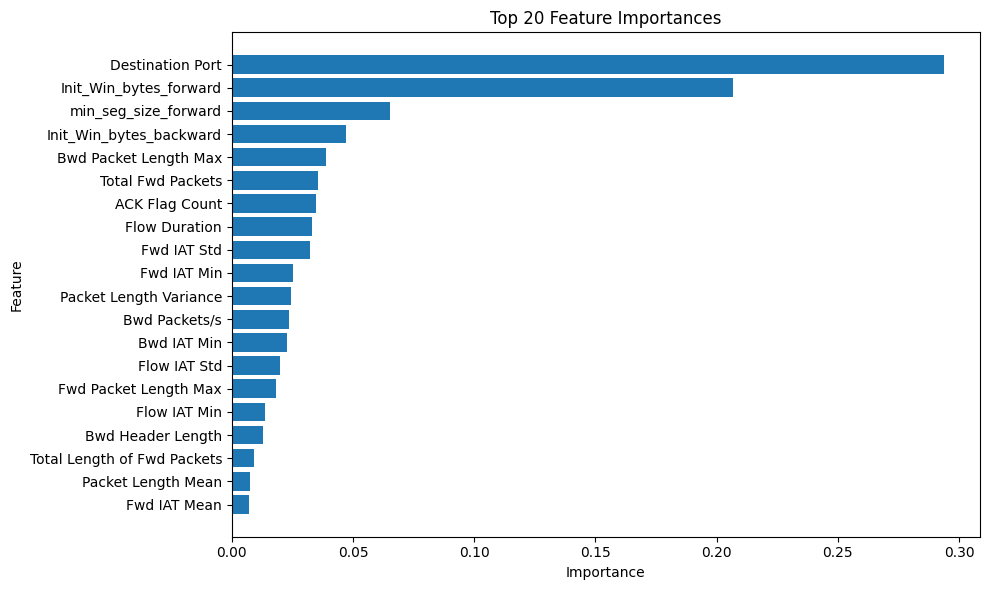

In [12]:
# 12) Feature importance (if model supports it)

if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_

    feat_imp_df = pd.DataFrame({
        "Feature": selected_columns,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    print("Top 20 important features:")
    display(feat_imp_df.head(20))

    plt.figure(figsize=(10, 6))
    top_feats = feat_imp_df.head(20).sort_values("Importance")
    plt.barh(top_feats["Feature"], top_feats["Importance"])
    plt.title("Top 20 Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("This model does not support feature importance.")

In [13]:
# 13) Sample predictions table

sample_count = min(30, len(y_test))

sample_df = pd.DataFrame({
    "Actual_Label": true_labels[:sample_count],
    "Predicted_Label": pred_labels[:sample_count]
})

sample_df["Correct?"] = np.where(
    sample_df["Actual_Label"] == sample_df["Predicted_Label"],
    "Yes",
    "No"
)

print(f"First {sample_count} predictions:")
display(sample_df)

First 30 predictions:


,Actual_Label,Predicted_Label,Correct?
0,BENIGN,BENIGN,Yes
1,BENIGN,BENIGN,Yes
2,BENIGN,BENIGN,Yes
3,BENIGN,BENIGN,Yes
4,BENIGN,BENIGN,Yes
5,BENIGN,BENIGN,Yes
6,FTP-Patator,FTP-Patator,Yes
7,DoS Hulk,DoS Hulk,Yes
8,DDoS,DDoS,Yes
9,BENIGN,BENIGN,Yes


In [14]:
# 14) Save evaluation outputs

output_dir = "../data/evaluation"
os.makedirs(output_dir, exist_ok=True)

metrics_df.to_csv(os.path.join(output_dir, "overall_metrics.csv"), index=False)
report_df.to_csv(os.path.join(output_dir, "classification_report.csv"))
label_metrics.to_csv(os.path.join(output_dir, "label_wise_metrics.csv"), index=True)
sample_df.to_csv(os.path.join(output_dir, "sample_predictions.csv"), index=False)

print("Evaluation files saved in:", output_dir)

Evaluation files saved in: ../data/evaluation
